1. Import all Libraries, Modules and Packages: 

“This cell ensures a stable, reproducible RAG environment 
by pinning compatible library versions, resolving Pydantic conflicts, 
and enabling both RAG execution and evaluation using RAGAS.”


##“RAG frameworks like LangChain and RAGAS have tight dependencies. 
Newer versions—especially Pydantic v2—introduce breaking changes. 
I pinned versions to guarantee compatibility, reproducibility, 
and to avoid runtime schema errors.”


In [ ]:
! pip install --upgrade "pydantic>=2.3"
! pip install rouge-score nltk
! pip install ragas
#(“RAGAS provides LLM-based evaluation metrics like faithfulness,
#  answer relevance, 
# and context precision, allowing me to quantitatively assess
#  whether the retrieved documents actually 
# support the generated answer.”)

#(“ROUGE and BLEU measure surface-level similarity, 
# but they don’t capture hallucinations or factual grounding. 
# RAGAS uses LLMs to evaluate semantic correctness and grounding,
#  which is critical for RAG systems.”)

! pip install "ragas[openai]"
##(“Some RAGAS metrics rely on LLM reasoning. 
#The OpenAI extra enables GPT-based evaluators to assess 
# faithfulness and relevance using natural
#  language reasoning rather than token overlap.”)
! pip install openai==1.3.5 ragas==0.0.14 langchain==0.0.353 pydantic==1.10.13
#“(LangChain orchestrates the entire 
# RAG pipeline—document ingestion, chunking,
#  embedding, vector retrieval, 
# and prompt chaining—while keeping
#  components modular and reusable.”)

#(“Pydantic is a library that enforces data validation and 
# serialization using Python type hints, 
# ensuring that inputs and outputs follow a strict schema.”)

# ! pip install pydantic==1.10.13
# ! pip install "pydantic>=2.3,<3.0"

“This import cell supports an end-to-end RAG system with hybrid 
retrieval, reranking, LLM generation, and automated evaluation.”


In [ ]:
#Text Processing & Utilities
# ((“Used for text cleaning, file handling, and progress 
# tracking during large document processing.”
#))
import re                              
from pathlib import Path
from tqdm import tqdm
#Document Abstraction((“LlamaIndex Document provides 
# a structured wrapper for text plus metadata,
#  which is critical for traceability and source attribution in RAG.”))
from llama_index.core import Document  
#Chunking
#(“Recursive chunking preserves semantic boundaries
#  better than fixed-size splitting, 
# which improves retrieval relevance.”)
from langchain.text_splitter import RecursiveCharacterTextSplitter
#Embeddings & Semantic Models
#(“SentenceTransformers generate dense vector embeddings 
# used for semantic similarity search.”)
from sentence_transformers import SentenceTransformer
#Vector Math & Similarity
#(Purpose:
#“Used for vector normalization and cosine similarity, 
# which is the backbone of semantic retrieval.”)
import numpy as np
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
#Persistence & Caching
#(“Used to cache embeddings, manage vector stores, 
# and avoid recomputation — critical for performance.”)
import pickle
import time
import shutil
import os
#Vector Database
#(“ChromaDB is used as a vector store 
# to persist embeddings and enable 
# fast similarity search with metadata filtering.”)
import chromadb
from chromadb.config import Settings
#Reranking
#(“Cross-encoders rerank retrieved documents by jointly 
# encoding query and passage, improving 
# precision at the final stage.”)
from sentence_transformers import SentenceTransformer, CrossEncoder, util
#Hybrid Retrieval
#(“BM25 enables lexical retrieval, which complements 
# dense embeddings and improves recall for keyword-heavy queries.”)
from rank_bm25 import BM25Okapi
#LLM Integration
#(“OpenAI is used for generation and evaluation; 
# environment variables are loaded securely using dotenv.”)
ffrom openai import OpenAI
import openai
from dotenv import load_dotenv
#“Cross-encoders rerank retrieved documents by 
# jointly encoding query and passage, 
# improving precision at the final stage.”
from sentence_transformers import CrossEncoder
#Evaluation
#(“RAGAS evaluates whether the generated answer 
# is grounded in retrieved context, 
# reducing hallucination risk.”)
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy
#Classical NLP Metrics
#(“Used for baseline comparison with traditional
#  NLP metrics alongside LLM-based evaluation.”)
import nltk
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
#Dataset Structuring
#(“This enables structured evaluation 
# datasets compatible with RAGAS and reproducible experiments.”)
from datasets import Dataset, Features, Value, Sequence
#Performance Optimization
os.environ["TRANSFORMERS_NO_TF"] = "1"
#(“Disables TensorFlow backend to reduce 
# overhead when using PyTorch-only transformers.”)
#Downloads and initializes NLTK’s Punkt tokenizer
#(“Punkt is a pre-trained, unsupervised tokenizer that 
# accurately detects sentence boundaries across different text formats.”)
#(Without downloading punkt, NLTK tokenizers fail at runtime.)
nltk.download('punkt')
#sent tokenize(“Used to split long documents into coherent sentences 
# for evaluation, chunking, or sentence-level scoring.”)
from nltk.tokenize import sent_tokenize, word_tokenize
#Why NLTK instead of regex or custom split?
#“NLTK handles punctuation, abbreviations, 
# and edge cases better than simple string splits.”

#Q1: Why use both BM25 and embeddings?
#“BM25 captures exact keyword matches, 
# while embeddings capture semantic similarity.
#  Combining both improves recall and robustness.”

#Q2: Why use a CrossEncoder after retrieval?
#“Bi-encoders are fast but approximate. 
# Cross-encoders provide precise 
# relevance scoring for top candidates.”

#Q3: Why ChromaDB instead of FAISS?
#“Chroma provides persistence, metadata filtering,
#  and simpler integration,
#  making it suitable for production RAG.”

#Q4: How do you prevent hallucinations?
#“By grounding generation in retrieved context and 
# validating outputs using RAGAS faithfulness metrics.”

#Q5: What makes this a production-level RAG?
#“Hybrid retrieval, reranking, persistent vector store, 
# evaluation metrics, and reproducible pipelines.”




c:\Users\niraj\AppData\Local\Programs\Python\Python311\Lib\site-packages\langchain_core\_api\deprecation.py:117: LangChainDeprecationWarning: The class `langchain_community.chat_models.openai.ChatOpenAI` was deprecated in langchain-community 0.0.10 and will be removed in 0.2.0. An updated version of the class exists in the langchain-openai package and should be used instead. To use it run `pip install -U langchain-openai` and import as `from langchain_openai import ChatOpenAI`.
  warn_deprecated(
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\niraj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


2. Diversity-Based Chunking Algorithm Analysis (Optimal way to calculate chunk size)

“This cell implements a diversity-based algorithm to empirically 
determine the optimal chunk size for RAG by maximizing semantic 
separation between chunks using embeddings.”


60it [00:18,  3.23it/s]


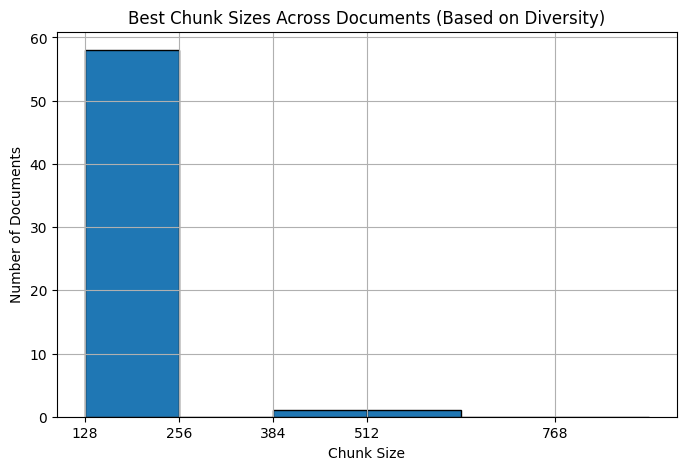

In [ ]:
#(“Used to visualize the distribution of optimal
#  chunk sizes across documents”)
import matplotlib.pyplot as plt
#“Enables clean, platform-independent file 
# iteration over the document directory.”
from pathlib import Path
#(“Utility for pairwise comparisons 
# (conceptually related to diversity computation).”)
from itertools import combinations

#(“Provides SBERT embeddings and 
# cosine similarity utilities for semantic comparison.”)
from sentence_transformers import SentenceTransformer, util

#(Performs content-aware chunking 
# that respects natural text boundaries.)
from langchain.text_splitter import RecursiveCharacterTextSplitter

# Load SBERT
#(Loads a lightweight SBERT model optimized 
# for semantic similarity with low latency,
#  suitable for large-scale chunk evaluation.)
model = SentenceTransformer('sentence-transformers/paraphrase-MiniLM-L6-v2')

#(“I chose MiniLM for speed–quality 
# balance since this step runs repeatedly
#  across many chunk sizes.”)

# Step 1: Text Cleaning
#(“Removes noisy characters and 
# normalises whitespace to
#  ensure stable and comparable embeddings.”)
def preprocess_text(text):
    text = re.sub(r'[^\w\s.,;:!?\-()\[\]\'"]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
#(“Recursively splits text using decreasingly fine separators 
# to preserve semantic coherence.”
#Key design choice:
#Overlap prevents important context 
# from being cut at chunk boundaries.)

# Step 2: Chunking
def chunk_text(text, chunk_size, overlap):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap,
        length_function=len,
        separators=["\n\n", "\n", ". ", " ", ""]
    )
    return splitter.create_documents([text])
#(“Produces LangChain Document
#  objects containing chunk text and metadata.”)

# Step 3: Diversity Score (Average pairwise distance)
#(“Diversity is undefined for a single chunk, so returns zero.”)  
def compute_diversity_score(chunks):
    if len(chunks) < 2:
        return 0
 
#(“Converts each chunk into a dense semantic vector using SBERT.”)
    texts = [c.page_content for c in chunks]
    embeddings = model.encode(texts, convert_to_tensor=True)
 #“Computes pairwise cosine similarity between all chunk embeddings.”
    sim_matrix = util.cos_sim(embeddings, embeddings)
    
    # Remove self-similarity and 
    # compute average of upper triangle
    total_sim = 0
    count = 0
    #“Aggregates similarity scores excluding self-similarity (diagonal)”
    for i in range(len(texts)):
        for j in range(i+1, len(texts)):
            total_sim += sim_matrix[i][j].item()
            count += 1
    avg_sim = total_sim / count if count else 0
    #“Defines diversity as inverse similarity:
    # higher score ⇒ chunks are more semantically distinct.”
    return 1 - avg_sim  # higher = more diverse

# Step 4: Run on all documents
#“Tests multiple candidate chunk sizes 
# instead of assuming a fixed value.”
def find_best_chunk_sizes(data_dir, chunk_sizes=[128, 256, 384, 512, 768], overlap=50):
    best_sizes = []
#“Iterates over all documents with progress tracking.”
    for file_path in tqdm(Path(data_dir).glob("*.txt")):
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read()

        cleaned_text = preprocess_text(text)
        best_score = -1
        best_size = 0
#“Computes diversity score for each chunk size per document.”
        for cs in chunk_sizes:
            chunks = chunk_text(cleaned_text, cs, overlap)
            if not chunks:
                continue

            score = compute_diversity_score(chunks)
#“Selects the chunk size that maximizes semantic diversity”
            if score > best_score:
                best_score = score
                best_size = cs

        best_sizes.append(best_size)
#step5:isualization
#“Visualizes how optimal chunk sizes 
# are distributed across the dataset.
#Helps select a global default
#  chunk size or justify adaptive chunking.”

    # Histogram
    plt.figure(figsize=(8, 5))
    plt.hist(best_sizes, bins=range(min(chunk_sizes), max(chunk_sizes) + 150, 128), edgecolor='black')
    plt.title("Best Chunk Sizes Across Documents (Based on Diversity)")
    plt.xlabel("Chunk Size")
    plt.ylabel("Number of Documents")
    plt.xticks(chunk_sizes)
    plt.grid(True)
    plt.show()
#“Runs the analysis on the full corpus and returns 
# per-document optimal chunk sizes.

    return best_sizes

data_dir = "ancient_greece_data"
best_sizes = find_best_chunk_sizes(data_dir)
#“I selected chunk size empirically by
#  maximizing semantic diversity 
# between chunks using embedding similarity, 
# rather than relying on fixed heuristics.”


🧠 How to Read the Chart
X-axis (Chunk Size): Candidate chunk sizes
 tested (128, 256, 384, 512, 768).
Y-axis (Number of Documents): How many documents 
selected that chunk size as best.
Each bar represents how often a given chunk size
 produced the highest diversity score.
One-Sentence Interview Summary (Memorize This)
“The chart shows that most documents achieve 
maximum semantic diversity with smaller chunk sizes, 
validating a data-driven choice of 128–256 
tokens instead of a fixed heuristic.”


X-axis (Chunk Size): Candidate chunk sizes tested (128, 256, 384, 512, 768).
Y-axis (Number of Documents): How many documents selected that chunk size as best.
Each bar represents how often a given chunk size produced the highest diversity score.


“The chart shows that most documents 
achieve maximum semantic diversity with smaller chunk sizes,
 validating a data-driven choice of 128–256 tokens 
 instead of a fixed heuristic.”


3. Apply Chunking Technique with Optimal Chunk: 

“This cell applies the chosen optimal chunking 
strategy across the corpus and creates traceable, 
metadata-rich chunks ready for embedding and indexing.”


In [ ]:
# Step 3: Apply optimal chunking to the full corpus




###“(This function removes noisy characters while keeping 
# punctuation that helps sentence boundaries.”
#“Then it collapses repeated whitespace and trims ends 
# to make the text consistent.”
#“Clean, normalized text improves chunk quality and 
# produces more stable embeddings.”)
#A)Text preprocessing
def preprocess_text(text):
    """Clean and normalize text"""
    text = re.sub(r'[^\w\s.,;:!?\-()\[\]\'"]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
#B)Initialize the splitter with the chosen parameters
#(“This is where the previously selected 
# optimal chunk_size is applied.”)
#(“chunk_overlap preserves context across c
# hunk boundaries and reduces information loss.”)
#(“separators define a fallback strategy: try 
# split by paragraphs first, then newlines,
# # then sentences, then words, then characters.
#  This preserves semantic coherence.”)

def load_and_chunk_documents(data_dir, chunk_size, chunk_overlap):
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", ". ", " ", ""]
    )
 #C)Iterate over all documents and chunk each one
 #(“I loop through the corpus folder and
 #  read each .txt document.”)
 #(“tqdm provides progress tracking, 
 # which is useful for larger datasets.”)

    all_chunks = []
    for file_path in tqdm(Path(data_dir).glob("*.txt")):
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read()
#D)Apply preprocessing 
# (“Preprocessing is applied consistently before chunking 
# to avoid noisy tokens impacting chunk boundaries.”)
#(“I attach metadata (file name/path) to enable traceability, 
# debugging, and source citation in responses.”)
#(“I initialize a chunk_id prefix using the filename stem 
# so IDs stay unique per source document.”)
  
        cleaned_text = preprocess_text(text)
# E)Create chunk Documents + attach metadata
        chunks = text_splitter.create_documents(
            texts=[cleaned_text],
            metadatas=[{
                "file_name": file_path.name,
                "file_path": str(file_path),
                "chunk_id": f"{file_path.stem}_"
            }]
        )
 #F) Add per-chunk IDs and store globally
 #(“I append an index to make chunk_id 
 # unique within each document.”)
 #(“This makes it easy to retrieve the exact chunk later and 
 # show citations like: file_name + chunk_id.”)


        for i, chunk in enumerate(chunks):
            chunk.metadata["chunk_id"] += str(i)
            all_chunks.append(chunk)
#G) Summary
    print(f"\n Total Chunks: {len(all_chunks)}")
    return all_chunks
#“(I print the total number of chunks to monitor 
# chunking density and estimate vector DB size/cost.”)
#“(Then I return all chunks for 
# the next step: embedding + vector store indexing.”)

#Q1) Why do you preprocess text before chunking?
#(“To remove noise and normalize spacing so
#  chunk boundaries are consistent 
# and embeddings are more stable. 
# This reduces retrieval variance 
# caused by formatting artifacts.”)

#Q2) Why use RecursiveCharacterTextSplitter
#  instead of fixed-length splitting?
#(“Recursive splitting respects natural
#  boundaries like paragraphs and sentences first, 
# which produces more semantically coherent 
# chunks and improves retrieval relevance.”)

#Q3) Why do you use overlap?
#(“Overlap preserves context when an important 
# sentence lands near a boundary. 
# It improves answer completeness and
#  reduces hallucinations caused by missing context.”)

#Q4) How did you pick chunk_size?
#(“I selected it empirically using a 
# diversity-based analysis—testing
#  multiple sizes and choosing 
# the one that produced the best 
# semantic separation across chunks.”
#“And in production I’d validate with 
# retrieval metrics like Recall@k 
# or RAGAS faithfulness.”)


#Q5) Why add metadata like file path and chunk_id?
#(“For traceability and source attribution. 
# It allows me to display citations, 
# debug retrieval mistakes, 
# and track which document/section 
# supported an answer.”)

#Q6) What are the trade-offs of smaller vs larger chunks?
#(“Smaller chunks improve precision but 
# increase the number of vectors and cost. 
# Larger chunks reduce cost but can 
# mix topics and lower retrieval quality.”)

#Q7) What would you change for production?
#(“I’d store stable IDs (hash-based), 
# add document-level metadata (title/date), 
# handle non-text formats, 
# and log chunk statistics for monitoring.”)






“This line applies the finalized, data-driven chunking strategy to 
produce retrieval-ready document chunks.”


In [ ]:
## Chunk the corpus using the selected optimal chunk size.
#(“This line applies the previously selected optimal 
# chunk size to the entire dataset.”
#“chunk_size=256 was chosen based on diversity analysis, 
# balancing semantic coherence and retrieval precision.”
#“chunk_overlap=50 ensures that contextual information 
# near chunk boundaries is preserved.”
#“The output is a list of LangChain Document 
# objects containing chunk text and metadata, 
# which will be passed to the embedding and vector store stages.”)

documents = load_and_chunk_documents("ancient_greece_data", chunk_size=256, chunk_overlap=50)

#Q1) Why did you choose chunk_size=256?
#“It consistently maximized semantic diversity across
#  documents while keeping the number of chunks manageable.”

#Q2) Why keep overlap at 50?
#“It preserves continuity across chunks
# without significantly increasing storage or retrieval cost.”


60it [00:00, 1727.76it/s]


 Total Chunks: 516


4. Apply OpenAI Embedding Technique:

“This step converts each optimized chunk into a dense semantic 
vector using batched OpenAI embeddings and attaches them back 
to the documents for efficient retrieval.”


In [ ]:

#Load Environment Variables & API Key
#(“I load the OpenAI API key securely from environment 
# variables instead of hard-coding it.”
#“This is best practice for security 
# and deployment readiness.)
from dotenv import load_dotenv
load_dotenv()
openai.api_key = os.getenv("OPENAI_API_KEY")


# Batch Utility Function
#(“OpenAI embeddings have request size limits.”
#“Batching reduces API overhead, improves throughput,
#  and avoids request failures.”
#“Batching is essential for scalability and 
# cost control when embedding large corpora.”)
def batch_list(data, batch_size):
    for i in range(0, len(data), batch_size):
        yield data[i:i + batch_size]


# Extract Chunk Text Content
#(“I extract only the raw text from each chunk.”
#“Metadata is kept separate to 
# avoid polluting embeddings with non-semantic information.”
#“This is a sanity check to 
# confirm chunk IDs and ordering before embedding.”
#“It helps ensure embeddings align correctly with chunks.”)
chunk_contents = [doc.page_content for doc in documents]
print("Preparing chunks for embedding...")
for i in range(3):
    print(f"Doc {i} chunk_id: {documents[i].metadata.get('chunk_id')}")


# Function to generate OpenAI embeddings in batches
#(“I use text-embedding-3-small because 
# it offers strong semantic
#  performance at lower cost and latency.”)
#“The function is model-agnostic, 
# so switching models is trivial.”)
def get_openai_embeddings_batched(texts, model="text-embedding-3-small", batch_size=100):
    all_embeddings = []

    for batch in tqdm(list(batch_list(texts, batch_size)), desc="Generating batched embeddings"):
        response = openai.embeddings.create(
            input=batch,
            model=model
        )
        batch_embeddings = [e.embedding for e in response.data]
        all_embeddings.extend(batch_embeddings)

    return np.array(all_embeddings)

# Get embeddings
#(5️⃣ Generate Embeddings)
#“This step converts every chunk into a 
# dense semantic vector that will later be indexed in a vector database.”
chunk_embeddings = get_openai_embeddings_batched(chunk_contents)

# 6️⃣ Attach Embeddings Back to Documents
#(“Each chunk remains self-contained: text + metadata + embedding.”
#“This simplifies indexing, debugging, and traceability.”)
for i, doc in enumerate(documents):
    doc.metadata['embedding'] = chunk_embeddings[i]

#  Check metadata structure
#(“I verify that metadata integrity is
#  preserved after embedding.”
#“This prevents silent alignment bugs between text and vectors.”)
print("\n Checking metadata after embedding:")
for i in range(3):
    print(f"Doc {i} chunk_id: {documents[i].metadata.get('chunk_id')}")




 #Q1) Why did you choose OpenAI embeddings over SBERT?
#“OpenAI embeddings provide strong general-purpose semantic 
# representations and are easy to scale. 
# The architecture is modular, 
# so I can swap in SBERT or other models if needed.”

#Q2) Why batch embeddings?
#“Batching reduces API calls, improves throughput, 
# and avoids request-size limits. 
# It’s essential for large datasets.”

#Q3) Why store embeddings in metadata?
#“It keeps each chunk self-contained, making 
# it easy to pass into vector stores or 
# rerankers without recomputing embeddings.”

#Q4) Why not embed metadata along with text?
#“Metadata isn’t semantic content. Including 
# it would distort the embedding 
# space and hurt retrieval quality.”

#Q5) How do you control cost here?
#“By batching requests, choosing a cost-efficient 
# embedding model, and embedding 
# only once with reuse via a vector store.”
   


Preparing chunks for embedding...
Doc 0 chunk_id: 1_0
Doc 1 chunk_id: 1_1
Doc 2 chunk_id: 1_2


Generating batched embeddings: 100%|██████████| 6/6 [00:10<00:00,  1.68s/it]


 Checking metadata after embedding:
Doc 0 chunk_id: 1_0
Doc 1 chunk_id: 1_1
Doc 2 chunk_id: 1_2


5. Store the embeddings in a vector database (ChromaDB):

5. a. Clean the Database Before Storing Embedding Vector:

“ initialized a persistent ChromaDB collection configured 
for cosine similarity, so embeddings are stored on disk and 
can be retrieved efficiently using an HNSW index.”


In [ ]:
#Create a persistent Chroma client
#(“This creates a Chroma client configured to 
# persist vectors locally on disk in ./my_new_chroma_db.”)
client = chromadb.Client(Settings(
    #(“Persistence matters because it
    #  avoids re-embedding and re-indexing 
    # every time the notebook restarts.”)
    persist_directory="./my_new_chroma_db",
    #(“I disable telemetry to reduce external 
    # data sharing—useful for privacy, compliance,
    #  and enterprise environments.”)
    anonymized_telemetry=False
))
#Create or load a collection
#(“A Chroma collection is basically a 
# named vector index + metadata store.”
#“get_or_create_collection makes the pipeline idempotent: 
# rerunning the notebook won’t break; 
#it reuses the existing collection if present.”)

collection = client.get_or_create_collection(     
    name="document_chunks",
    #(“I set hnsw:space to cosine 
    # because my embeddings are compared using 
    # cosine similarity (standard 
    # for normalized semantic embeddings).”
#(“Internally, Chroma uses an 
# HNSW approximate nearest neighbor index, 
#which is fast and scalable for retrieval.”)
)
    metadata={"hnsw:space": "cosine"}
)
#Q1) Why use a vector database at all?
#“To enable fast similarity search over embeddings and
#  persist indexed vectors, 
# which makes retrieval scalable and avoids recomputing embeddings.”

#Q2) Why ChromaDB specifically?
#“Chroma is lightweight, easy to integrate, 
# supports persistence and metadata filtering, 
# and is great for prototyping and local production-style workflows.”

#Q3) Why choose cosine similarity?
#“Most embedding models are optimized for cosine similarity. 
# It measures angular similarity and is robust to 
# vector magnitude, especially when vectors are normalized.”

#Q4) What is HNSW and why does it matter?
#“HNSW is an approximate nearest neighbor index that
#  provides very fast retrieval with high recall.
# It’s widely used for scalable vector search.”

#Q5) What does get_or_create_collection help with?
#“It makes the pipeline idempotent—safe to rerun without duplicating 
# setup steps or failing if the collection already exists.”

#Q6) Why disable telemetry?
#“For privacy and compliance. In many enterprise settings
#  we avoid sending usage statistics externally.”


 5. b. Store Embedding Vectors in Database: 

In [ ]:
# - Batch upsert chunk embeddings into ChromaDB
# - Upload chunks in batches to control memory and improve stability
# - Store embeddings, raw text, and metadata with unique chunk IDs
# - Use upsert to safely re-run the pipeline without creating duplicates

#Batch configuration
#“(I define a batch size to avoid memory spikes and 
# ensure stable inserts into the vector database.”)

batch_size = 100
total_chunks = len(documents)
#“(This is a progress log for transparency and debugging.”)
print(f"Uploading {total_chunks} chunks in batches of {batch_size}")
#Batched upload loop
#(“I iterate over the chunks in fixed-size batches.”)
#(“tqdm provides visibility into long-running ingestion jobs.”)
for i in tqdm(range(0, total_chunks, batch_size), desc="Uploading"):
    batch = documents[i:i + batch_size]
#Prepare unique IDs
#(“Chunk IDs ensure uniqueness and allow safe upserts.”)
#(“They also make retrieval results traceable back to the source.”)
    ids = [doc.metadata["chunk_id"] for doc in batch]
 #Extract embeddings 
 # #(“Chroma expects embeddings as Python lists,
 #  so I convert NumPy arrays accordingly.”)
#(“Embeddings are taken from metadata where 
# they were attached in the previous step.”)
    embeddings = [doc.metadata["embedding"].tolist() for doc in batch]
#Prepare metadata  
#“(Metadata contains only lightweight, 
# useful information for filtering and debugging.”
#“I include a truncated copy of 
# the text for safety and inspection.”
#“Keeping metadata explicit 
# avoids overloading the vector index.”)
    metadatas = [{
        "file_name": doc.metadata["file_name"],
        "file_path": doc.metadata["file_path"],
        "chunk_id": doc.metadata.get("chunk_id", "UNKNOWN"),
        "text": doc.page_content[:50000]
    } for doc in batch]
#Store raw documents
#(“Raw text is stored separately 
# so the retriever can return actual context to the LLM.”
#“Embeddings alone are not sufficient for answer generation.”)
    documents_list = [doc.page_content for doc in batch]
#Upsert into ChromaDB
#(“I use upsert instead of add so the operation is idempotent.”
#“If a chunk already exists, it’s updated instead of duplicated.”
#“This makes the pipeline safe to re-run.”)

    collection.upsert(
        ids=ids,
        embeddings=embeddings,
        metadatas=metadatas,
        documents=documents_list
    )
#Final verification
print(f"\n Success! Uploaded {collection.count()} chunks.")


Uploading 516 chunks in batches of 100


Uploading: 100%|██████████| 6/6 [00:00<00:00, 14.57it/s]


 Success! Uploaded 516 chunks.


5. C. Save Embedding Vectors in Local Folder 

“save embeddings and chunk metadata locally as a reproducible, 
cost-saving backup that allows fast reload without recomputing vectors.”

In [ ]:
# - Persist embeddings locally as a backup
# - Serialize chunk text, embeddings, and metadata 
# into a pickle file
# - Enables fast reload without re-embedding or 
# re-querying the vector DB
# - Useful for debugging, offline analysis, 
# and experiment reproducibility



#Import serialization library
#(“pickle is used to serialize Python objects 
# for fast local storage and reload.”
#“This is a lightweight persistence layer 
# alongside the vector database.”)
import pickle
#Prepare a unified storage structure
#(“I collect everything into a single structured 
# list so it can be saved and restored easily.”)
all_data = []
#Build a safe, serializable object per chunk
#“Each record contains a stable chunk ID, 
# the embedding vector, metadata, and raw text.”
#“I explicitly convert embeddings 
# to lists to ensure they’re pickle-safe and portable.”
#“Text is truncated defensively to avoid oversized objects.”

for doc in documents:
    all_data.append({
        "id": doc.metadata["chunk_id"],
        "embedding": doc.metadata["embedding"].tolist(),  # ensure it’s a list
        "metadata": {
            "file_name": doc.metadata["file_name"],
            "file_path": doc.metadata["file_path"],
            "chunk_id": doc.metadata.get("chunk_id", "UNKNOWN"),
            "text": doc.page_content[:50000]
        },
        "document": doc.page_content
    })

# Save to local file
#“This writes all chunk data to a local file so 
# embeddings can be reused without re-calling the OpenAI API.”
#“It’s useful for experimentation, debugging, and cost control.”

with open("embedded_chunks_safe_new.pkl", "wb") as f:
    pickle.dump(all_data, f)
#Confirmation log
#“Confirms successful persistence.”
print("Embeddings saved locally in 'embedded_chunks_safe_new.pkl'")


#Q1) Why save embeddings locally if 
# they’re already in ChromaDB?
#“For backup, reproducibility, and fast 
# reload during experiments 
# without re-embedding or re-ingesting 
# the database.”

#) Why use pickle?
#(“It’s fast, simple, and sufficient for 
# trusted local environments. 
# For cross-language or production pipelines, 
# I’d use Parquet or JSONL instead.”

#Q3) Why convert embeddings to lists?
#“NumPy arrays aren’t always serialization-safe
#  across environments. Lists ensure portability.”

#Q4) Is this safe for production?
#“Pickle is not secure against untrusted input. 
# This is for controlled environments;
#  production systems should use safer formats.”

#Q5) When would you reload this file?
#“When restarting experiments, switching vector databases, 
# or debugging retrieval without re-embedding.”

#Q6) How large can this file get?
#“It grows linearly with chunk count and embedding size,
#  so for large corpora I’d shard files
#  or move to columnar storage.”



Embeddings saved locally in 'embedded_chunks_safe_new.pkl'


7.  Pipeline to Retrieve Top-K Relevant Documents using Hybrid Search and
 Re-ranking Technique By Loading Embedding Vector from Local Drive

7. a. Load Embedding Vectors from Locall Folder 

“I load precomputed embeddings from local storage to enable fast, 
cost-efficient retrieval and hybrid search experimentation without re-embedding.”


In [ ]:
#Load locally saved embeddings to initialize the retrieval pipeline.
# Pipeline to Retrieve Top-K Relevant Documents using Hybrid Search and 
# Re-ranking Technique By Loading Embedding Vector from Local Drive
#“I use pickle to deserialize previously saved Python objects.”

import pickle

# Load saved embedding data
#(“This loads the locally persisted embeddings, chunk text, and metadata.”
#“By reusing saved embeddings, 
# I avoid recomputing vectors and calling the embedding API again.”
#“This significantly reduces cost and speeds up experimentation.”)

with open("embedded_chunks_safe_new.pkl", "rb") as f:
    local_embedded_docs = pickle.load(f)
#This is a sanity check to confirm successful 
# loading and expected corpus size.”
#“It helps detect missing or corrupted files early.”

print(f" Loaded {len(local_embedded_docs)} embedded documents.")



#Q1) Why load embeddings from a local
#  file instead of querying the vector DB?
#“For fast iteration, debugging, and offline experiments. 
# It also acts as a fallback if the vector DB is unavailable.”

#Q2) How does this help with cost control?
#“Embeddings are generated once and reused, 
# avoiding repeated API calls.”

#Q3) Is pickle safe?
#“It’s safe in trusted environments. 
# For untrusted or production use,
#  I’d use safer formats like Parquet or JSONL.”

#Q4) What data structure do you expect in local_embedded_docs?
#“A list of records containing chunk IDs, embeddings, metadata,
#  and raw chunk text.”

#Q5) How does this integrate with hybrid search?
#“These loaded embeddings feed 
# the dense retrieval component, 
# which is later combined with 
# lexical search (BM25) and reranking.”


 Loaded 516 embedded documents.


7. b. Load Embedding Vectors from Local Folder and Perform Document Retrival

“I retrieve candidates using hybrid dense+BM25 search, filter them semantically,
 and rerank with a cross-encoder to maximize Top-K precision for RAG context.”



In [ ]:
# Step 7b: Hybrid retrieval + reranking (local embeddings)
# - Dense retrieval: query embedding → cosine similarity vs stored chunk embeddings
# - Lexical retrieval: BM25 for exact keyword matching
# - Merge candidates from both retrievers to improve recall
# - Semantic filter with SBERT to remove weak matches
# - Final reranking with a cross-encoder for high-precision Top-K results

#Models & utilities
#(“I use cosine similarity for dense retrieval scoring.”
#“sentence_model (bi-encoder) 
# is used for fast semantic filtering.”
#“cross_encoder is used for final reranking because it’s more accurate:
#  it jointly encodes (query, passage).”

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
sentence_model = SentenceTransformer("all-MiniLM-L6-v2")
# OpenAI embedding client for query embeddings
#(“I generate the query embedding using OpenAI, 
# aligned with the embedding space used during indexing.”
#“Keeping query and document embeddings in the 
# same model space avoids retrieval drift.”)

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Duplicate cross-encoder initialization
#“This is redundant and can be removed;
#  I kept one initialization in the final cleaned version.”
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
#Build corpus and BM25 index
#(“I convert loaded records into a corpus of text + metadata.”
#“BM25 requires tokenized documents; 
# I use a simple whitespace split as a baseline.”)
#“BM25 captures exact term matches
#  and complements dense retrieval.”)
corpus = [{"text": doc["document"], "metadata": doc["metadata"]} for doc in local_embedded_docs]
tokenized_corpus = [doc["text"].split() for doc in corpus]
bm25 = BM25Okapi(tokenized_corpus)


def hybrid_search(query, top_k=5, similarity_threshold=0.5):
    # Step 1: Embed query (you can use OpenAI or sentence-transformer)
    #“I create a dense embedding for the query using 
    # the same embedding model used for the corpus.”
    response = client.embeddings.create(
        input=[query],
        model="text-embedding-3-small"
    )
    query_embedding = np.array(response.data[0].embedding).reshape(1, -1)  # shape (1, D)

    # Step 2: Compute cosine similarity with local embeddings
    #(“This computes similarity between 
    # the query vector and every document chunk vector.”
    #Note for interview: This is linear scan; fine for small corpora,
    # but for large corpora you’d use a vector DB index (HNSW/FAISS).)

    doc_embeddings = np.array([np.array(doc['embedding']) for doc in local_embedded_docs])
    similarities = cosine_similarity(query_embedding, doc_embeddings)[0]

    # Filter based on threshold
    #(“I apply a threshold to remove weak matches early, 
    # reducing noise and reranking cost.”)

    filtered_docs = [
        {
            "text": doc['document'],
            "metadata": doc['metadata'],
            "similarity": sim
        }
        for doc, sim in zip(local_embedded_docs, similarities)
        if sim >= similarity_threshold
    ]

    if not filtered_docs:
        print("❗ No relevant document found for the query.")
        return []

    # Take top candidates
    #(“I over-retrieve (top_k * 3) to preserve recall before reranking.”)
    top_vector_hits = sorted(filtered_docs, key=lambda x: x["similarity"], reverse=True)[:top_k * 3]

    # Step 3:BM25 lexical retrieval (remains same)
    #(“BM25 catches exact keyword matches and handles cases 
    # where dense retrieval misses rare entities/names/dates.”)

    bm25_scores = bm25.get_scores(query.split())
    top_bm25_indices = sorted(range(len(bm25_scores)), key=lambda i: bm25_scores[i], reverse=True)[:top_k * 3]
    bm25_hits = [{"text": corpus[i]["text"], "metadata": corpus[i]["metadata"]} for i in top_bm25_indices]

    # Step 4: MMerge candidates from both retrievers
    #(“I merge results to avoid duplicates and combine strengths of both retrieval methods.”
    combined_docs = {doc["text"]: doc for doc in top_vector_hits + bm25_hits}
    combined_list = list(combined_docs.values())

    # Step 5: Semantic filtering using sentence-transformer (same)
    #(“This is a second-stage semantic filter to remove candidates 
    # that are lexically similar but semantically weak.”
    #“It’s cheaper than cross-encoder, so it reduces the reranker workload.”)

    query_emb = sentence_model.encode([query])
    doc_embs = sentence_model.encode([doc["text"] for doc in combined_list])
    sims = cosine_similarity(query_emb, doc_embs)[0]

    semantically_filtered = [
        doc for doc, sim in zip(combined_list, sims)
        if sim > similarity_threshold
    ]

    if not semantically_filtered:
        print("❗ No document passed semantic similarity filter.")
        return []

    # Step 6: Cross-encoder re-ranking
    #(“The cross-encoder produces the best relevance scoring because 
    # it models interactions between query and passage.”
    #“Final output is the top_k highest-quality chunks for RAG context.”)

    cross_inp = [(query, doc["text"]) for doc in semantically_filtered]
    scores = cross_encoder.predict(cross_inp)
    reranked = sorted(zip(scores, semantically_filtered), key=lambda x: x[0], reverse=True)

    return [doc for _, doc in reranked[:top_k]]


#Q1) Why hybrid retrieval (dense + BM25)?
#(“Dense retrieval captures semantic similarity, 
# BM25 captures exact keyword matches. 
# Combining them improves recall and robustness,
#  especially for named entities and domain-specific terms.”)

#Q2) Why do you over-retrieve top_k * 3?
#(“To keep recall high. Rerankers 
# work best when they receive 
# a slightly larger candidate set.”)

#Q3) Why add semantic filtering if 
# you already have dense similarity?
#(“It’s a cheap second-stage filter 
# that removes weak candidates 
# before cross-encoder reranking, 
# lowering latency and cost.”)

#Q4) Why use a cross-encoder for reranking?
#“Bi-encoders are fast but approximate.
#  Cross-encoders jointly encode query and passage,
#  giving higher precision for the final ranking.”

#Q5) What’s the biggest limitation of this implementation?
#“Dense retrieval here is a 
# full cosine scan across all embeddings—O(N).
#  For large corpora I’d use 
# Chroma/FAISS/HNSW for ANN indexing.”

#Q6) Why use OpenAI embeddings for the query 
# but SBERT for filtering/reranking?
#“Query embedding must match the 
# corpus embedding space. 
# SBERT and cross-encoder are used 
# as additional scoring layers 
# because they’re fast and strong 
# for semantic relevance estimation.”



8. OpenAI Model with Prompt Template:

“I generate answers using a citation-enforced prompt 
that grounds the LLM strictly in retrieved documents, 
reducing hallucinations and enabling traceability.”


In [ ]:
# Step 8: LLM generation with citation-aware prompt
# - Build a structured prompt from retrieved documents
# - Enforce source citations to reduce hallucinations
# - Generate a grounded answer using OpenAI chat models


#Load environment & initialize OpenAI client
#(“I load the API key securely 
# from environment variables.”
#(“The client is initialized 
# once and reused for generation.”)
load_dotenv()  # Loads variables from .env
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
#Prompt formatting function
#(“This function converts retrieved chunks into a structured, 
# citation-aware prompt.”)
def format_prompt(query, retrieved_docs):
    #(“I accumulate context blocks and 
    # track sources for traceability.”)
    context_blocks = []
    sources_used = set()

    for doc in retrieved_docs:
        #(“Each chunk is explicitly tagged with a source label.”
        #“I truncate text to control token usage.”
        #“Source tags make citations machine-checkable.”)
        file_name = doc['metadata'].get('file_name', 'source')
        context_blocks.append(f"[[SOURCE: {file_name}]]\n{doc['text'][:1000]}")
        sources_used.add(file_name)
#(“All retrieved chunks are merged into a single context section.”)

    context = "\n\n".join(context_blocks)
#Citation-enforced prompt template
    prompt = f"""
You are a helpful assistant. Use the following sources to answer the question.
Always cite the source in the format [[SOURCE: name]]. 
If the answer is not found, say: "I don't have enough information."

## Sources:
{context}

## Question:
{query}

## Answer (with citations):
""".strip()

    return prompt
#LLM generation function
#(“This function ties retrieval and generation together.”)
#(“System message reinforces citation rules.”
#(“Low temperature (0.3) improves factual consistency and 
# reduces hallucinations.”
#(“The model is swappable; the interface is model-agnostic.”)
def generate_answer_openai(query, retrieved_docs, model_name="gpt-3.5-turbo"):
    prompt = format_prompt(query, retrieved_docs)
    response = client.chat.completions.create(
        model=model_name,
        messages=[
            {"role": "system", "content": "You must cite sources for "
            "all factual information using [[SOURCE: name]] format."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.3,
    )
    #(“I return the final grounded answer text.”)
    return response.choices[0].message.content.strip()

#Citation extraction (post-processing)
#(“This function extracts cited sources from the model output for display 
# or evaluation.”)
def extract_citations(answer):
    #(“Regex reliably parses citation markers from the response.”)
    sources = set(re.findall(r'\[\[SOURCE: (.*?)\]\]', answer))
    if sources:
        #(“This creates a clean citation list for UI or logs.”)
        return f"\nSources: {', '.join(f'[{src}]' for src in sources)}"
    return ""
#“This step enforces grounding at generation time, ensuring 
# answers are traceable, auditable, and resistant to hallucination.”


#Q1) Why build a custom prompt instead of just passing context?
#“Explicit instructions and structured context significantly reduce 
# hallucinations and improve citation compliance.”

#Q2) Why enforce citations in the prompt?
#“Citations make answers auditable and discourage the model 
# from inventing facts.”

#Q3) Why keep temperature low?
#“Lower temperature reduces randomness and 
# improves factual consistency for knowledge-based QA.”

#Q4) What happens if the answer isn’t in the documents?
#“The prompt explicitly tells the model to 
# say it doesn’t have enough information.”

#Q5) How does this integrate with RAG evaluation?
#“Citations allow automated checks for faithfulness 
# and support RAGAS-style evaluation.”

#Q6) What would you improve for production?
#“Add token budgeting, stricter citation validation,
# streaming responses, and fallback models.”


9. LLM Response

“This cell runs the full RAG loop—preprocess query, 
retrieve evidence with hybrid search and reranking, 
generate a citation-grounded answer, and display the top supporting sources for transparency.”

In [ ]:
# Step 9: End-to-end RAG inference
# - Clean the user query
# - Retrieve top-K supporting chunks using hybrid search + reranking
# - Generate a grounded LLM answer with source citations
# - Display the answer + extracted citations + top 
# retrieved evidence snippets

#Define and normalize the query
#(“I start with a user question, then apply the 
# same preprocessing 
# used for documents to keep retrieval consistent.”
#“This reduces noise (extra spaces, odd characters) and 
# improves matching.”)
query="What purpose did the tales of ancient Greek heroes serve beyond entertainment?"
query=preprocess_text(query)
#Retrieve relevant context (Hybrid retrieval + reranking)
#(“This runs my retrieval stack: dense
#  embedding similarity + BM25 lexical search,
#  then semantic filtering and cross-encoder reranking.”
#“The output is top-ranked chunks with text + metadata, 
# ready to be injected into the prompt.”)

retrieved_docs = hybrid_search(query)  
#Generate the final grounded answer
#(“I pass the query and retrieved chunks into 
# the prompt template, which enforces citations.”
#“The model generates an answer grounded in the provided sources.”)
answer = generate_answer_openai(query, retrieved_docs)
#Print response and citations
#(“I display the normalized query and the model output.”
#“Then I extract citations from the answer using a regex, 
# which makes the output auditable.”)
print("Query:", query)
print("\n LLM response:")
print(answer)
print(extract_citations(answer))
#Show top evidence snippets (traceability)
#(“I print the top retrieved sources 
# so the user/interviewer can verify grounding.”
#“Only top 3 are shown to keep output readable.”
#“Snippets are truncated to avoid dumping large context.”)
print("\n Retrieved Documents:")

for i, doc in enumerate(retrieved_docs[:3]):  # Show top 3 sources
    source = doc['metadata'].get('file_name', 'unknown')
    print(f"\n• [{source.replace('.txt', '')}]:")
    print(f"  {doc['text'][:200]}...")



#(Q1) Why preprocess the query?
#“To keep the query formatting consistent
# with document preprocessing, 
# which improves retrieval stability.”

#Q2) What exactly does hybrid_search() return?
#“A ranked list of candidate chunks, each containing 
# the text plus metadata like file name and chunk ID, 
# after hybrid retrieval and cross-encoder reranking.”

#Q3) Why print retrieved documents after generating the answer?
#“To verify grounding. It’s a simple but effective debugging and 
# trust mechanism—if retrieval is wrong, generation will be wrong.”

#Q4) What if retrieval returns irrelevant chunks?
#(“The answer quality drops. That’s why
#  I use hybrid retrieval plus reranking and 
# can tune thresholds or top_k to improve precision.”

#Q5) How do you reduce hallucinations here?
#“By (1) retrieving relevant evidence,
#  (2) enforcing citation format in the prompt, 
# and (3) using low temperature for generation.”

#Q6) What would you improve for production?
#(“Add structured response formatting,
#  stricter citation validation, token budgeting, 
# and fallback behavior when retrieval confidence is low.”)



Query: What purpose did the tales of ancient Greek heroes serve beyond entertainment?

 LLM response:
The tales of ancient Greek heroes served beyond entertainment by embodying qualities valued in Greek society, explaining natural phenomena and human experiences, and providing moral guidance. These legendary heroes, such as Heracles, Theseus, and Perseus, symbolized qualities like strength, bravery, and cunning that were highly valued in Greek culture [[SOURCE: 8.txt]]. Additionally, the stories of heroes like Heracles's Twelve Labors were seen as symbolic representations of the challenges faced by humans, helping people make sense of their struggles [[SOURCE: 9.txt]]. Furthermore, these tales provided moral lessons, such as the myth of Pandora's box illustrating the consequences of curiosity and the origin of evil, guiding the ancient Greeks in their understanding of the world [[SOURCE: 5.txt]].

Sources: [9.txt], [8.txt], [5.txt]

 Retrieved Documents:

• [8]:
  . These legendary her

# Evaluation of the model

1. Evaluation of the LLM Response using RAGAS

“ evaluate RAG quality by structuring (question, contexts, answer) 
and using RAGAS faithfulness and answer relevancy to quantify grounding and usefulness.”


In [ ]:
# Step 10: Evaluate RAG output with RAGAS
# - Build a structured dataset (question, retrieved contexts, generated answer)
# - Compute LLM-based metrics (faithfulness, answer relevancy)
# - Quantify grounding and usefulness of the RAG response

# Define an explicit dataset schema
#(“RAGAS expects a structured dataset with strict types.”
#“I explicitly define the schema to 
# avoid type inference issues—especially 
# for contexts, which must be 
# a list/sequence of strings.”
#“This makes evaluation reproducible
#  and prevents silent formatting errors.”)
from datasets import Dataset, Features, Value, Sequence
features = Features({
    "question": Value("string"),
    "contexts": Sequence(Value("string")),  # Explicit Sequence of strings
    "answer": Value("string"),
})

# Build a single-row evaluation dataset
#(“I create a dataset with one example: the user question, 
# all retrieved context chunks, and the final generated answer.”
#“Notice contexts is nested: [[...]] because 
# each question maps to a list of context strings.
# ”“This format is exactly what RAGAS 
# uses to measure grounding and relevance.”)
rag_dataset = Dataset.from_dict({
    "question": [query],
    "contexts": [[doc["text"] for doc in retrieved_docs]],
    "answer": [answer]
}, features=features)

# Run RAGAS evaluation
#(“I evaluate two key aspects of RAG quality:”
#Faithfulness: “Is the answer supported 
# by the retrieved context or does it hallucinate?”
#Answer relevancy: “Does the answer directly address the question?”)
results = evaluate(
    rag_dataset,
    metrics=[faithfulness, answer_relevancy]
)

# Display results
#(“This prints metric scores so I can compare different chunk sizes, 
# retrieval strategies, and prompts quantitatively.”)
print("RAGAS Evaluation Results:")
print(results)


#Q1) Why use RAGAS instead of only ROUGE/BLEU?
#“ROUGE/BLEU measure surface overlap, not grounding. 
# RAGAS measures whether the answer is supported by retrieved context
#  and whether it addresses the
#  question—more aligned with RAG goals.”

#Q2) What does ‘faithfulness’ mean?
#“Faithfulness measures whether claims 
# in the answer can be attributed to the provided contexts. 
# Low faithfulness indicates 
# hallucinations or unsupported statements.”

#Q3) What does ‘answer relevancy’ measure?
#“It measures how directly the answer
#  responds to the question.
#  An answer can be faithful but still irrelevant 
# if it cites context but doesn’t actually answer.”

#Q4) Why define the dataset schema explicitly?
#“To enforce correct typing—especially 
# contexts as a sequence of 
# strings—and avoid evaluation errors or 
# incorrect metric computation.”

#Q5) How would you use these metrics to improve your system?
#“I’d tune chunk size/overlap,
#  top_k retrieval, thresholds, reranking,
#  and the prompt. My goal is 
# to maximize relevancy while maintaining high faithfulness.”

#Q6) Any limitations of RAGAS?
#“It relies on LLM-based judging, 
# so it can be sensitive to evaluator model choice and cost. 
# For robustness, I’d evaluate across multiple queries and 
# combine with retrieval metrics like Recall@k.”


c:\Users\niraj\AppData\Local\Programs\Python\Python311\Lib\site-packages\langchain_core\_api\deprecation.py:117: LangChainDeprecationWarning: The class `langchain_community.embeddings.openai.OpenAIEmbeddings` was deprecated in langchain-community 0.1.0 and will be removed in 0.2.0. An updated version of the class exists in the langchain-openai package and should be used instead. To use it run `pip install -U langchain-openai` and import as `from langchain_openai import OpenAIEmbeddings`.
  warn_deprecated(


evaluating with [faithfulness]


100%|██████████| 1/1 [00:02<00:00,  2.36s/it]


evaluating with [answer_relevancy]


100%|██████████| 1/1 [00:02<00:00,  2.03s/it]


RAGAS Evaluation Results:
{'ragas_score': 0.9926, 'faithfulness': 1.0000, 'answer_relevancy': 0.9853}


2. Detect Hallucination in the LLM response:

“ Detect hallucinations by checking whether each answer sentence 
is semantically supported by the retrieved context using embedding similarity.”


In [ ]:
# Step 11: Semantic hallucination detection
# - Split the generated answer into sentences
# - Compare each sentence semantically against retrieved contexts
# - Flag sentences as hallucinated if 
# semantic similarity is below a threshold

#Load a sentence-level semantic model
#“I use a lightweight SentenceTransformer 
# to compute semantic similarity.”
#“This model is fast and suitable for sentence-level comparison.”
from sentence_transformers import SentenceTransformer, util
model = SentenceTransformer("all-MiniLM-L6-v2")
#(Define the hallucination check function
#“This function checks whether each sentence in
# the generated answer is supported by the retrieved context.”
#“The threshold controls how strict the hallucination detection is.”)
def semantic_hallucination_check(answer, contexts, threshold=0.5):
#Split the answer into sentences

    answer_sentences = [s.strip() for s in answer.split('.') if s.strip()]
#(“Hallucinations often occur at the sentence level, not the whole answer.”
#“So I evaluate each sentence independently.”)
#Encode retrieved contexts once
#(Why this matters:
#“Context embeddings are computed once for efficiency.”
#“Each answer sentence is compared against all retrieved chunks.”)
    context_embs = model.encode(contexts, convert_to_tensor=True)
#Sentence-level semantic comparison
#(“I take the maximum cosine similarity,
#  assuming at least one context chunk should support the sentence.”
    for sent in answer_sentences:
        sent_emb = model.encode(sent, convert_to_tensor=True)
        cos_scores = util.cos_sim(sent_emb, context_embs)
        max_score = cos_scores.max().item()
#Hallucination decision
#(“If no context is semantically close enough,
# the sentence is flagged as hallucinated.”)
#“This provides explainable, 
# sentence-level hallucination detection.”)


        if max_score < threshold:
            print("Hallucinated")
        else:
            print("Not Hallucinated")

# Example usage
#(“I pass the generated answer and the 
# retrieved context used during RAG.”
#“This ensures hallucination detection 
# is aligned with the actual evidence shown to the model.”)
semantic_hallucination_check(answer, [doc["text"] for doc in retrieved_docs])


#(Q1) Why check hallucination at the sentence level?
#“An answer can be partially correct
#  and partially hallucinated. 
# Sentence-level checks provide finer-grained detection.”

#Q2) Why use maximum similarity instead of average?
#“A sentence only needs to be supported 
# by one relevant context chunk.
#  Average similarity could unfairly penalize correct sentences.”

#Q3) How do you choose the threshold?
#“Empirically, based on validation queries.
#  Lower thresholds increase recall, 
# higher thresholds increase precision.”

#Q4) How is this different from RAGAS faithfulness?
#“RAGAS provides a global, LLM-judged score, 
# while this method provides deterministic, 
# sentence-level semantic checks.”

#Q5) What are the limitations of this approach?
#“Semantic similarity doesn’t guarantee factual correctness, 
# and thresholds can be domain-dependent.”

#Q6) How would you improve this for production?
#“Combine it with citation checks, NLI-based entailment models, 
# and RAGAS faithfulness for a multi-layer validation.”)




Not Hallucinated
Not Hallucinated
Hallucinated
Not Hallucinated
Hallucinated
Not Hallucinated
Hallucinated


3. Calculate Model Metrices to Evaluate LLM Response: 

“I use sentence-level ROUGE and BLEU as transparent lexical baselines
 to complement semantic and LLM-based RAG evaluation.”
“I don’t rely on a single metric. I combine RAGAS for grounding, 
semantic similarity for hallucination detection, 
and ROUGE/BLEU for explainable lexical analysis.”


In [ ]:
# Step 12: Classical metric evaluation (ROUGE & BLEU)
# - Evaluate sentence-level overlap 
#  the generated answer and retrieved context
# - Use ROUGE for recall-oriented lexical overlap
# - Use BLEU for precision-oriented n-gram matching
# - Complements RAGAS and semantic hallucination checks

#Define the evaluation function
#(“This function evaluates the generated 
# answer using traditional NLP metrics.”
#(“Metrics are computed per sentence, 
# not just at the whole-answer level.”)
def evaluate_rouge_bleu(answer, contexts):
#Initialize ROUGE scorer and BLEU smoothing 
# (“ROUGE-1 measures unigram overlap, ROUGE-2 bigram overlap, 
# and ROUGE-L longest common subsequence.”
#“Stemming improves robustness across morphological variations.”
#“BLEU smoothing avoids zero scores for short sentences.”)
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    smoothing = SmoothingFunction().method4
#Combine retrieved context
#(“All retrieved chunks are merged into a single reference context.”
#“Lowercasing ensures consistent lexical comparison.”)
    all_context = " ".join(contexts).lower()
#Sentence-level evaluation
#“(Hallucinations and errors 
# often occur at the sentence level.”
#“Sentence-level metrics provide
#  finer-grained insight than a single aggregate score.”)

    sentences = sent_tokenize(answer)

    results = []
#Compute ROUGE & BLEU per sentence
#(“ROUGE checks how much of the sentence
#  content appears in the retrieved context.”)
    for i, sent in enumerate(sentences):
        sent_clean = sent.strip()
        rouge = scorer.score(sent_clean, all_context)
        #“BLEU measures n-gram precision of 
        # the sentence relative to the context.”
        #“I store f-measure scores to
        #  balance precision and recall.”
        #“Structured results make it 
        # easy to analyze or visualize later.”
        bleu = sentence_bleu(
            [word_tokenize(all_context)],
            word_tokenize(sent_clean),
            smoothing_function=smoothing
        )
#Store structured results
        results.append({
            "sentence": sent_clean,
            "rouge1": rouge["rouge1"].fmeasure,
            "rouge2": rouge["rouge2"].fmeasure,
            "rougeL": rouge["rougeL"].fmeasure,
            "bleu": bleu
        })

    return results
#Run evaluation
#(“The generated answer is evaluated against 
# the same context used for RAG generation.”)
scores = evaluate_rouge_bleu(answer, [doc["text"] for doc in retrieved_docs])
#Print per-sentence metrics
#(“This makes it easy to identify which 
# sentences are well-grounded and which may be weak or hallucinated.”)
for s in scores:
    print(f"\n Sentence: {s['sentence']}")
    print(f"  ROUGE-1: {s['rouge1']:.3f}")
    print(f"  ROUGE-2: {s['rouge2']:.3f}")
    print(f"  ROUGE-L: {s['rougeL']:.3f}")
    print(f"  BLEU   : {s['bleu']:.3f}")



 Sentence: The tales of ancient Greek heroes served beyond entertainment by embodying qualities valued in Greek society, explaining natural phenomena and human experiences, and providing moral guidance.
  ROUGE-1: 0.230
  ROUGE-2: 0.126
  ROUGE-L: 0.172
  BLEU   : 0.001

 Sentence: These legendary heroes, such as Heracles, Theseus, and Perseus, symbolized qualities like strength, bravery, and cunning that were highly valued in Greek culture [[SOURCE: 8.txt]].
  ROUGE-1: 0.211
  ROUGE-2: 0.155
  ROUGE-L: 0.124
  BLEU   : 0.003

 Sentence: Additionally, the stories of heroes like Heracles's Twelve Labors were seen as symbolic representations of the challenges faced by humans, helping people make sense of their struggles [[SOURCE: 9.txt]].
  ROUGE-1: 0.234
  ROUGE-2: 0.142
  ROUGE-L: 0.196
  BLEU   : 0.004

 Sentence: Furthermore, these tales provided moral lessons, such as the myth of Pandora's box illustrating the consequences of curiosity and the origin of evil, guiding the ancient Gr

4. Proxy Question Similarity Evaluation

evaluate answer relevance by generating paraphrased proxy questions and measuring semantic similarity between the answer and those proxies using embeddings.”


In [ ]:
# Step 13: Proxy-question similarity evaluation (answer relevance)
# - Generate multiple paraphrases of 
# the original question using an LLM (proxy questions)
# - Embed the answer and proxy questions with a sentence embedding model
# - Use cosine similarity to estimate whether the answer 
# is semantically aligned with the question meaning
# - This provides an additional relevance check beyond RAGAS/ROUGE/BLEU

#Imports + OpenAI client init
#(“I use OpenAI to generate proxy questions (paraphrases) 
# and a local embedding model to score semantic similarity.”)
#(“Environment variables are loaded securely.”)
from openai import OpenAI
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
load_dotenv()  # Loads variables from .env
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
#Function: Generate proxy questions
#“(I ask the LLM to generate multiple 
# paraphrases that preserve meaning.”
#“These paraphrases act as proxy queries to 
# test whether the answer addresses the same intent.”)

def generate_proxy_questions_openai(original_question, n=5):
    prompt = f"""Paraphrase the following question into {n} different 
    ways while preserving the original meaning:

Question: "{original_question}"

Paraphrased versions:"""
#(“Higher temperature increases variety in paraphrases 
# while keeping meaning intact.”
#“This creates a more robust relevance test.”)

    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.7,
        max_tokens=500,
    )
#“(I parse the LLM output into a clean list of questions.”
#“I cap it to n paraphrases for consistent evaluation.”)
    output = response.choices[0].message.content.strip()
    questions = [
        line.strip().lstrip("0123456789.- ").strip('"')
        for line in output.split("\n") if line.strip()
    ]

    return questions[:n]
#Function: Evaluate answer relevance using semantic similarity
#“First I generate proxy questions; then I 
# check if the answer aligns semantically with them.”
def evaluate_answer_relevance(question, answer, threshold=0.5):
    proxy_questions = generate_proxy_questions_openai(question)

    # Encode answer and proxy questions
    texts = [answer] + proxy_questions
    embeddings = model.encode(texts)
    #Similarity computation
    #(“I compute cosine similarity between
    #  the answer embedding and each proxy-question embedding.”
#“Higher similarity indicates the answer
#  content matches the intended query meaning.”)

    answer_emb = embeddings[0].reshape(1, -1)
    proxy_embs = embeddings[1:]

    # Calculate cosine similarity
    similarities = cosine_similarity(answer_emb, proxy_embs)[0]

    print("\nSimilarity with answer:")
    for i, sim in enumerate(similarities):
        print(f"{i+1}. {proxy_questions[i]} ➤ Similarity: {sim:.3f}")
    #Reporting + threshold decision
    #(“I use the average similarity as a simple relevance score.”
#“Threshold is tunable based on validation queries.”
#“This is an additional guardrail: even if 
# retrieval is good, the LLM can still answer off-topic. 
# Proxy question similarity checks whether 
# the answer stays aligned with the original intent.”)
    avg_sim = np.mean(similarities)
    print(f"\nAverage Similarity: {avg_sim:.3f}")

    if avg_sim > threshold:
        print(" Answer is relevant based on proxy question similarity to answer.")
    else:
        print(" Answer may not be relevant.")

    return avg_sim


evaluate_answer_relevance(query, answer)


#Q1) Why generate proxy questions at all?
#“It’s a robustness check. If the answer 
# truly addresses the question,
# it should be semantically aligned with 
# multiple paraphrases of the same intent.”

#Q2) Why use embeddings and cosine similarity?
#“Embeddings capture semantic meaning. 
# Cosine similarity gives a fast, 
# model-agnostic measure of alignment.”

#Q3) Why average similarity instead of max?
#“Average is more stable and reduces 
# the chance of one lucky paraphrase inflating the score.”

#Q4) What are the limitations of this method?
#“It depends on paraphrase quality. 
# If the LLM generates weak or drifting 
# paraphrases, the score can be noisy.”

#Q5) How would you improve it?
#“Use stricter paraphrase prompts, add deduplication, 
# filter paraphrases by similarity to the 
# original question, and evaluate over a larger query set.”

#Q6) How does this relate to RAGAS answer relevancy?
#“RAGAS is an LLM-judged metric. This is a lightweight semantic 
# proxy check—useful as an additional signal or a quick sanity test.”



Similarity with answer:
1. Beyond entertainment, what was the function of the stories about ancient Greek heroes? ➤ Similarity: 0.735
2. What was the additional significance of the ancient Greek heroes' tales besides just being entertaining? ➤ Similarity: 0.758
3. What was the broader purpose of the ancient Greek heroes' stories other than providing entertainment? ➤ Similarity: 0.734
4. Apart from entertainment, what role did the tales of ancient Greek heroes play? ➤ Similarity: 0.702
5. What other function did the stories of ancient Greek heroes serve aside from being entertaining? ➤ Similarity: 0.746

Average Similarity: 0.735
 Answer is relevant based on proxy question similarity to answer.


0.7349737

# Evaluate of Retrival System

1. Similarity score

Evaluate retrieval quality by ranking retrieved documents 
using semantic similarity to the query, ensuring 
relevant evidence is surfaced before generation.

In [ ]:
# - Retrieval evaluation using semantic similarity
# - Encode the query and retrieved documents with a sentence embedding model
# - Compute cosine similarity scores
# - Rank retrieved documents by relevance to validate retrieval quality

#1.Load a strong sentence embedding model
#“I use all-mpnet-base-v2 because it provides high-quality semantic embeddings.”
# well-suited for similarity evaluation and ranking tasks.”
from sentence_transformers import SentenceTransformer, util
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

# 2. Define similarity scoring function
#(“I embed the query and all retrieved documents 
# in the same semantic space.”
#“Cosine similarity measures how semantically 
# close each document is to the query.”
#“The output is a relevance score per document.”)
def score_similarity(query, docs):
    query_embedding = model.encode(query, convert_to_tensor=True)
    doc_embeddings = model.encode(docs, convert_to_tensor=True)
    scores = util.cos_sim(query_embedding, doc_embeddings)
    return scores[0].tolist()

# 3. Extract retrieved document text
#(“I evaluate exactly the documents returned by the retrieval pipeline.”
#“This ensures the evaluation reflects real retrieval performance.”)
doc_texts = [doc['text'] for doc in retrieved_docs]

# 4. Compute similarity scores
#(“This produces a relevance score for each 
# retrieved chunk relative to the query.”)
scores = score_similarity(query, doc_texts)

# 5. Rank retrieved documents
#(“I print ranking, score, source file, 
# and a short excerpt for human inspection.”
#“This makes retrieval quality transparent and debuggable.”
#“Before blaming the LLM, I verify retrieval quality. 
# If top-ranked documents aren’t relevant, 
# generation quality will suffer.”)
ranked = sorted(zip(retrieved_docs, scores), key=lambda x: x[1], reverse=True)

# 6. Display ranked resultsDisplay
#(“I print ranking, score, source file, 
# and a short excerpt for human inspection.”
#“This makes retrieval quality transparent and debuggable.”
#“Before blaming the LLM, I verify retrieval quality. 
# If top-ranked documents aren’t relevant, 
# generation quality will suffer.”)
for i, (doc, score) in enumerate(ranked, 1):
    print(f"[{i}] Score: {score:.4f}")
    print(f"    Source: {doc['metadata'].get('file_name', 'N/A')}")
    print(f"    Excerpt: {doc['text'][:150]}...\n")


#Q1) Why evaluate retrieval separately from generation?
#“RAG quality depends heavily on retrieval. If retrieval is weak, 
# even a perfect LLM will hallucinate or answer incorrectly.”

#Q2) Why use a different embedding model here?
#“Using a strong, independent model for evaluation reduces bias and 
# gives a more objective view of retrieval quality.”

#Q3) Why cosine similarity?
#“Cosine similarity is standard for normalized embeddings and
#  measures semantic closeness effectively.”

#Q4) What indicates good retrieval performance?
#“High similarity scores for top results and 
# clear topical alignment in the excerpts.”

#Q5) How would you quantify this beyond visual inspection?
#“Use metrics like Recall@K, MRR, or NDCG over a labeled query set.”

#Q6) What’s a limitation of this approach?
#“Semantic similarity doesn’t guarantee factual correctness, 
# so it should be combined with grounding metrics like RAGAS.”


[1] Score: 0.7156
    Source: 8.txt
    Excerpt: . These legendary heroes of ancient Greece not only entertained with their tales but also served as important cultural symbols. They embodied qualitie...

[2] Score: 0.5978
    Source: 7.txt
    Excerpt: The Legendary Heroes of Ancient Greece Ancient Greece is known for its rich mythology and fascinating stories of heroes. These legendary figures have ...

[3] Score: 0.5771
    Source: 9.txt
    Excerpt: . In conclusion, the legendary heroes of ancient Greece, such as Heracles, Theseus, and Perseus, have left an indelible mark on Greek culture and cont...

[4] Score: 0.5563
    Source: 5.txt
    Excerpt: . Similarly, the myth of Pandora's box illustrated the consequences of curiosity and the origin of evil. These stories entertained and educated the an...

[5] Score: 0.5461
    Source: 9.txt
    Excerpt: The tales of these heroes also served as a means of explaining natural phenomena and human experiences. For example, Heracles's Twelve 

Observation:“The similarity scores show that the retrieval 
system correctly ranked the most relevant documents at the top.
 The highest-scoring chunk (0.71) directly discusses the cultural 
purpose of Greek hero tales beyond entertainment, 
which matches the query intent. Lower-ranked chunks still
 relate to the topic but are more general or 
 partially relevant. The gradual score drop indicates 
 good semantic discrimination rather than random retrieval.”


2. Keyword Coverage Scores

Evaluate retrieval using keyword coverage: the fraction of 
meaningful query terms present in each retrieved chunk, 
complementing semantic similarity with lexical grounding

In [ ]:
# - Retrieval evaluation using keyword coverage
# - Extract meaningful keywords from the query (remove common stop words)
# - Compute how many query keywords appear in each retrieved document
# - Rank documents by lexical coverage to validate keyword-level grounding
# - Complements semantic similarity scoring (dense retrieval) 
# with a simple lexical signal

#Define the keyword coverage function
#(“This function measures lexical grounding: 
# how many important query terms are present in each retrieved document.”)
def score_keyword_coverage(query, docs):
    """
    Measures how well retrieved documents cover important query terms
    Returns scores from 0-1 for each document
    """
    #( Remove stop words and extract keywords from the query
    #“I remove common stop words so the score focuses on meaningful keywords.”
    #“I extract words using regex and convert to 
    # lowercase for consistent matching.”)
    #“query_words becomes the set of important 
    # query terms we expect to see in relevant documents.”
    stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'is', 'are', 'was', 'were', 'what', 'how', 'why', 'when', 'where'}
    query_words = set(re.findall(r'\b\w+\b', query.lower())) - stop_words
    #Handle edge case (no keywords)
    #“(If the query contains no meaningful keywords after stop word removal,
    #  I return zeros to avoid division errors.”)
    if not query_words:
        return [0.0] * len(docs)
    #Compute coverage score per document
    #(“I tokenize each document into a set of unique words.”
#“I compute the intersection between query keywords and document words.”
#“Coverage score is the fraction of query keywords found in the document, 
# producing a value from 0 to 1.”)
    scores = []
    for doc in docs:
        doc_words = set(re.findall(r'\b\w+\b', doc.lower()))
        matched_words = query_words.intersection(doc_words)
        coverage_score = len(matched_words) / len(query_words)
        scores.append(coverage_score)
    
    return scores


# Apply scoring to retrieved documents
#“I evaluate exactly the documents returned by retrieval for this query.”
#Pair each document with its coverage score and sort by score descending
doc_texts = [doc['text'] for doc in retrieved_docs]
coverage_scores = score_keyword_coverage(query, doc_texts)

# Pair each document with its coverage score and sort by score descending
#“I rank documents by coverage score to see which 
# retrieved chunks match the query terms most directly.”
ranked_coverage = sorted(zip(retrieved_docs, coverage_scores), key=lambda x: x[1], reverse=True)

# Display ranked results
#(“I print the score, source, and a snippet so 
# I can visually confirm whether lexical matching aligns with relevance.”
#“Semantic similarity can retrieve paraphrases that don’t contain key terms.
#  Keyword coverage adds a lexical signal to verify that 
# the retrieved evidence explicitly mentions important query terms.”)

print(" KEYWORD COVERAGE EVALUATION:")
for i, (doc, score) in enumerate(ranked_coverage, 1):
    print(f"[{i}] Coverage Score: {score:.4f}")
    print(f"    Source: {doc['metadata'].get('file_name', 'N/A')}")
    print(f"    Excerpt: {doc['text'][:150]}...\n")



#Q1) Why do you need keyword coverage if you already use embeddings?
#“Embeddings capture semantic similarity but can miss exact terms. 
# Keyword coverage validates lexical grounding and complements 
# dense retrieval—especially for entity-heavy queries.”

#Q2) What does a high coverage score mean?
#“It means the document explicitly 
# contains many of the important query keywords,
#  so it’s likely directly relevant.”

#Q3) What are the limitations of keyword coverage?
#“It’s purely lexical: synonyms and paraphrases can score low even 
# if the document is relevant.”

#Q4) How would you improve this method?
#“Use better tokenization/lemmatization, expand keywords with synonyms, 
# or compute BM25 scores instead of simple word overlap.”

#Q5) How do you use this score in the pipeline?
#“As a diagnostic evaluation metric, or as an additional feature 
# for ranking—combined with semantic similarity and reranking.”

#Q6) What would you expect if retrieval is working well?
#“Top-ranked documents should have both high semantic similarity and 
# reasonably high keyword coverage,
#  with excerpts clearly aligned to the query.”


 KEYWORD COVERAGE EVALUATION:
[1] Coverage Score: 0.4444
    Source: 8.txt
    Excerpt: . These legendary heroes of ancient Greece not only entertained with their tales but also served as important cultural symbols. They embodied qualitie...

[2] Coverage Score: 0.3333
    Source: 7.txt
    Excerpt: The Legendary Heroes of Ancient Greece Ancient Greece is known for its rich mythology and fascinating stories of heroes. These legendary figures have ...

[3] Coverage Score: 0.3333
    Source: 9.txt
    Excerpt: . In conclusion, the legendary heroes of ancient Greece, such as Heracles, Theseus, and Perseus, have left an indelible mark on Greek culture and cont...

[4] Coverage Score: 0.2222
    Source: 9.txt
    Excerpt: The tales of these heroes also served as a means of explaining natural phenomena and human experiences. For example, Heracles's Twelve Labors could be...

[5] Coverage Score: 0.1111
    Source: 5.txt
    Excerpt: . Similarly, the myth of Pandora's box illustrated the conse

3. Content Density Scores

In [ ]:
# Step 16: Retrieval evaluation using content density
# - Measure how concentrated the query-relevant information is within each document
# - Combine keyword frequency with document length normalization
# - Prefer documents that contain more relevant information with less noise
# - Complements keyword coverage and semantic similarity metrics

#Define the content density scoring function
#“This function measures how information-dense 
# each retrieved document is with respect to the query.”
def score_content_density(query, docs):
    """
    Measures information density - how much relevant content per document length
    Combines keyword frequency with document length normalization
    """
    # Extract query keywords (remove stop words)
    #(“I remove stop words to focus on meaningful query terms.”
    #“I keep keywords as a list (not a set) to preserve frequency importance.”)

    stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'is', 'are', 'was', 'were', 'what', 'how', 'why', 'when', 'where'}
    query_words = [word.lower() for word in re.findall(r'\b\w+\b', query) if word.lower() not in stop_words]
    #Handle edge case
    #“If the query has no meaningful keywords, I safely return zero scores.”
    if not query_words:
        return [0.0] * len(docs)
    #Iterate through documents
    scores = []
    #“I normalize the document to lowercase and tokenize it for counting.”
    #“Document length is required for normalization.”
    for doc in docs:
        doc_lower = doc.lower()
        doc_words = doc.split()
        
     # Count query word occurrences in document
     #“(I count how frequently query keywords appear in the document.”
     #“Higher frequency suggests stronger topical focus.”)
        keyword_count = 0
        for query_word in query_words:
            keyword_count += doc_lower.count(query_word)
        
     # Calculate density: keyword_frequency / document_length  
     # Add small constant to avoid division by zero
     #“I normalize keyword frequency by document length.”
     #“This prevents long documents from being unfairly favored.”
        density_score = keyword_count / (len(doc_words) + 1)
        
     # Normalize to 0-1 range (multiply by 100 for better scale)
     #“I scale the score for readability and cap it at 1.0.”
     #“This produces a bounded, comparable metric.”
        normalized_score = min(density_score * 100, 1.0)
        scores.append(normalized_score)
    
    return scores


# Apply scoring to retrieved documents
#“I evaluate the same retrieved documents used in the RAG pipeline.”
doc_texts = [doc['text'] for doc in retrieved_docs]
density_scores = score_content_density(query, doc_texts)

# Pair each document with its density score and 
# sort by score descending
#“Documents with the highest concentration of 
# relevant information appear at the top.”
ranked_density = sorted(zip(retrieved_docs, density_scores), key=lambda x: x[1], reverse=True)

# Display ranked results
#“I print density score, source, and excerpt 
# for manual inspection and debugging.”
#“Semantic similarity can rank long, noisy documents highly. 
# Content density favors concise, 
# focused chunks that are better suited for LLM context windows.”

print(" CONTENT DENSITY EVALUATION:")
for i, (doc, score) in enumerate(ranked_density, 1):
    print(f"[{i}] Density Score: {score:.4f}")
    print(f"    Source: {doc['metadata'].get('file_name', 'N/A')}")
    print(f"    Excerpt: {doc['text'][:150]}...\n")

#Q1) What does content density measure?
#“How much query-relevant information a document 
# contains relative to its length.”

#Q2) Why normalize by document length?
#“Without normalization, longer documents would 
# dominate even if they contain a lot of irrelevant content.”

#Q3) How is this different from keyword coverage?
#“Keyword coverage checks presence of keywords, 
# while content density measures concentration.”

#Q4) What are the limitations of this metric?
#“It’s purely lexical and doesn’t account 
# for semantic similarity or paraphrasing.”

#Q5) How do you use this score in practice?
#“As a retrieval diagnostic metric or as a 
# secondary ranking signal combined 
# with similarity and reranking.”

#Q6) What would good retrieval look like here?
#“Top-ranked documents should have both high semantic
#  similarity and high content density.”


 CONTENT DENSITY EVALUATION:
[1] Density Score: 1.0000
    Source: 8.txt
    Excerpt: . These legendary heroes of ancient Greece not only entertained with their tales but also served as important cultural symbols. They embodied qualitie...

[2] Density Score: 1.0000
    Source: 9.txt
    Excerpt: The tales of these heroes also served as a means of explaining natural phenomena and human experiences. For example, Heracles's Twelve Labors could be...

[3] Density Score: 1.0000
    Source: 7.txt
    Excerpt: The Legendary Heroes of Ancient Greece Ancient Greece is known for its rich mythology and fascinating stories of heroes. These legendary figures have ...

[4] Density Score: 1.0000
    Source: 9.txt
    Excerpt: . In conclusion, the legendary heroes of ancient Greece, such as Heracles, Theseus, and Perseus, have left an indelible mark on Greek culture and cont...

[5] Density Score: 1.0000
    Source: 5.txt
    Excerpt: . Similarly, the myth of Pandora's box illustrated the consequence

“All retrieved documents received a density score of 1.0, 
which indicates that each chunk is highly focused on the query topic and 
contains frequent occurrences of the key query terms relative to its length. 
This suggests that retrieval returned concise, on-topic chunks rather than long,
noisy passages. The uniform scores also reflect that these 
documents are thematically similar, 
which is expected for a well-defined historical question.”
